# Quality Assurance

This Notebook will help you to run the more advanced quality checks and to visualize the data produced:
- Advanced quality checks present in the envass library (https://github.com/eawag-surface-waters-research/envass/)
- Individual quality check: visualisation and selection of non-trusted data 
- Update changes into a json file and log.txt

As computational power is not unlimited and data are sometimes big, performing the visualization is highly recommended.


In [1]:
import json 
import copy
from functions import quality_flags, update_log
from functions import import_nc_files, json_converter, plot_data, plot_grid

### Import Data

In [2]:
folder = "../data/Level1/"
qa_file = '../quality_assurance.json'

In [3]:
ds = import_nc_files(folder, '20220303')
qa_original = json_converter(json.load(open(qa_file)))

ModuleNotFoundError: No module named 'dask'

### Plot Current Data

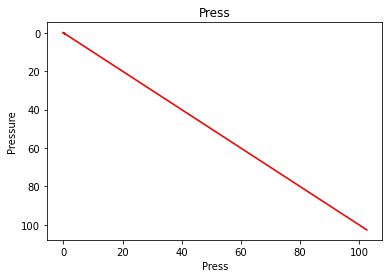

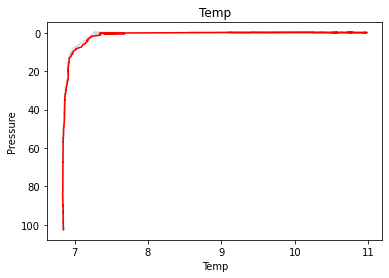

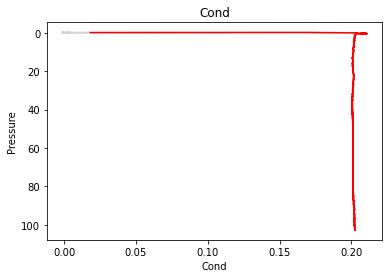

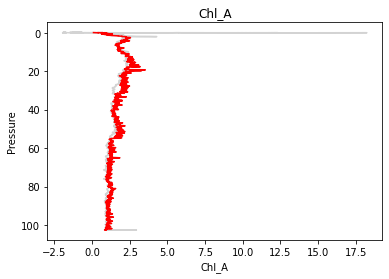

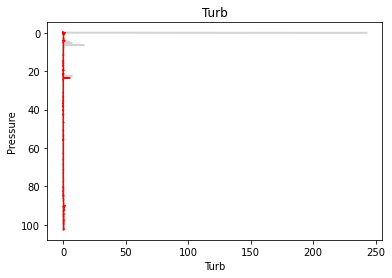

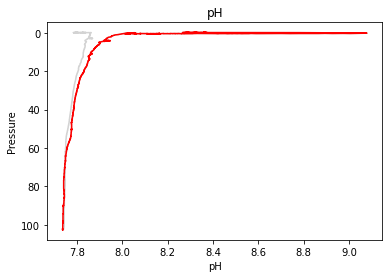

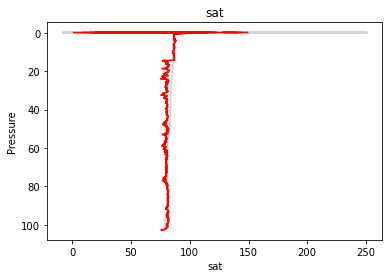

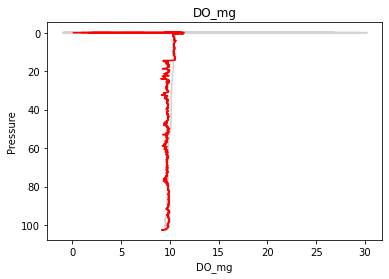

In [5]:
plot_data(ds, qa_original.keys())

### Experiment With Checks 

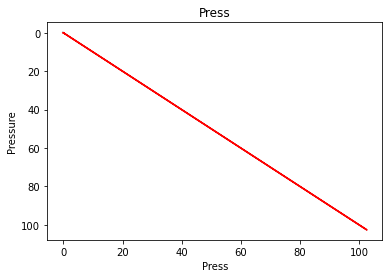

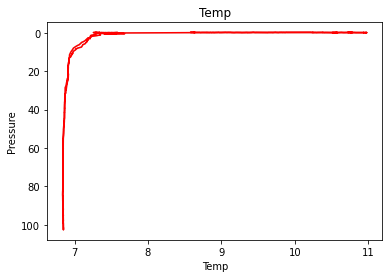

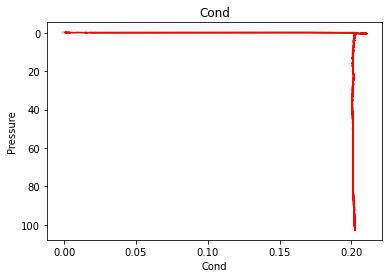

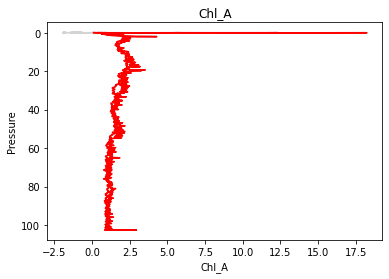

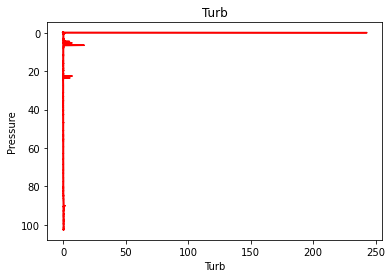

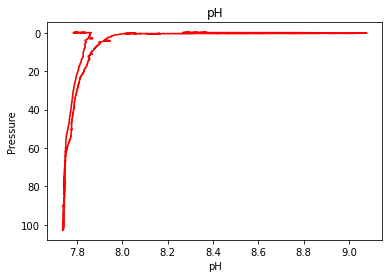

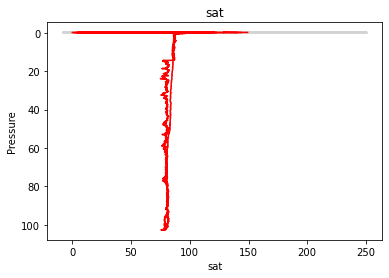

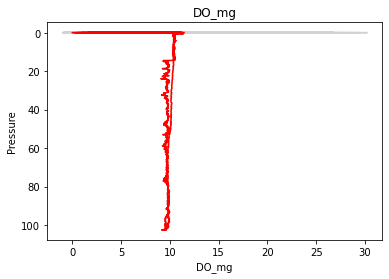

In [6]:
qa = copy.deepcopy(qa_original)
qa["DO_mg"]["simple"]["bounds"][1] = 11.5

ds = quality_flags(qa, ds, erase_qa=True)
plot_data(ds, qa.keys())

### Write QA to File

In [7]:
update_json=False
if update_json:
    qa["time"]["simple"]["bounds"][1] = "now"
    with open(qa_file, 'r+') as fp:
        json.dump(qa, fp)
    update_log(qa, qa_original, "DO_mg") 

# Grid Visualization

In [4]:
grid_folder = "../data/Level2B/"
ds_grid = import_nc_files(grid_folder, '2022')

ModuleNotFoundError: No module named 'dask'

In [5]:
plot_grid(ds_grid, "Temp_grid")

NameError: name 'ds_grid' is not defined